In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
trades = pd.read_csv('historical_data.csv')
sent = pd.read_excel('fear_greed_index.xlsx')

In [3]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
sent['date'] = pd.to_datetime(sent['date'])

In [4]:
df = trades.merge(sent[['date', 'classification']], on='date', how='left')
df = df.dropna(subset=['classification'])
print(df['classification'].value_counts())

Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: classification, dtype: int64


In [5]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

In [6]:
summary = df.groupby('classification').agg(
    trades=('Closed PnL', 'size'),
    pnl=('Closed PnL', 'sum'),
    volume=('Size USD', 'sum'),
    fee=('Fee', 'sum')
).reindex(order)

summary['return_pct'] = summary['pnl'] / summary['volume'] * 100
summary['avg_pnl'] = summary['pnl'] / summary['trades']

closed = df[df['Closed PnL'] != 0]
summary['win_rate'] = closed.groupby('classification')['Closed PnL'].apply(lambda x: (x > 0).mean()).reindex(order) * 100

print(summary)


                trades           pnl        volume           fee  return_pct  \
classification                                                                 
Extreme Fear     21400  7.391102e+05  1.144843e+08  23888.633939    0.645600   
Fear             61837  3.357155e+06  4.833248e+08  92456.948674    0.694596   
Neutral          37686  1.292921e+06  1.802421e+08  39374.268304    0.717325   
Greed            50303  2.150129e+06  2.885825e+08  63098.691979    0.745066   
Extreme Greed    39992  2.715171e+06  1.244652e+08  27030.665465    2.181471   

                  avg_pnl   win_rate  
classification                        
Extreme Fear    34.537862  76.215645  
Fear            54.290400  87.288647  
Neutral         34.307718  82.388898  
Greed           42.743559  76.890690  
Extreme Greed   67.892861  89.167026  


In [7]:
opens = df[df['Direction'].isin(['Open Long', 'Open Short'])]
bias = pd.crosstab(opens['classification'], opens['Direction'], normalize='index').reindex(order) * 100
print(bias)


Direction       Open Long  Open Short
classification                       
Extreme Fear    68.818155   31.181845
Fear            62.080736   37.919264
Neutral         61.671192   38.328808
Greed           42.280285   57.719715
Extreme Greed   45.119244   54.880756


In [8]:
acc = df.groupby('Account').agg(
    pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'size'),
    volume=('Size USD', 'sum')
).sort_values('pnl', ascending=False)

acc_sent = df.groupby(['Account', 'classification'])['Closed PnL'].sum().unstack().reindex(columns=order).fillna(0)
acc['good_regimes'] = (acc_sent > 0).sum(axis=1)
print(acc.head(10))

top5_share = acc['pnl'].head(5).sum() / acc['pnl'].sum()
print('top 5 accounts share:', top5_share)


                                                     pnl  trades  \
Account                                                            
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06   14733   
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06    3818   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05   21192   
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05   12236   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05   40184   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05    4356   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05    1590   
0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05    1237   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05    9893   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  3.605395e+05    1424   

                                                  volume  good_regimes  
Account                                                                 
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6b

In [9]:
daily = df.groupby('date').agg(pnl=('Closed PnL', 'sum'), volume=('Size USD', 'sum'), trades=('Closed PnL', 'size')).reset_index()
daily = daily.merge(sent[['date', 'value']], on='date', how='left').sort_values('date')
daily['cum_pnl'] = daily['pnl'].cumsum()

print(daily[['value', 'pnl', 'volume', 'trades']].corr())

           value       pnl    volume    trades
value   1.000000 -0.082642 -0.264371 -0.245241
pnl    -0.082642  1.000000  0.325759  0.360552
volume -0.264371  0.325759  1.000000  0.720137
trades -0.245241  0.360552  0.720137  1.000000


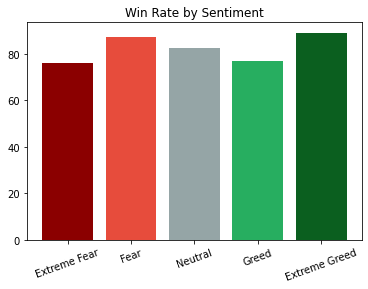

In [10]:
colors = ['#8B0000', '#E74C3C', '#95A5A6', '#27AE60', '#0B5F1F']

plt.figure(figsize=(6, 4))
plt.bar(order, summary['win_rate'], color=colors)
plt.title('Win Rate by Sentiment')
plt.xticks(rotation=20)
plt.savefig('chart1_winrate.png')
plt.show()

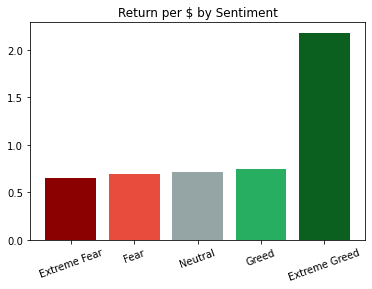

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(order, summary['return_pct'], color=colors)
plt.title('Return per $ by Sentiment')
plt.xticks(rotation=20)
plt.savefig('chart2_return.png')
plt.show()

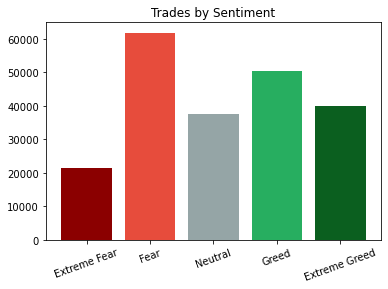

In [12]:
plt.figure(figsize=(6, 4))
plt.bar(order, summary['trades'], color=colors)
plt.title('Trades by Sentiment')
plt.xticks(rotation=20)
plt.savefig('chart3_trades.png')
plt.show()

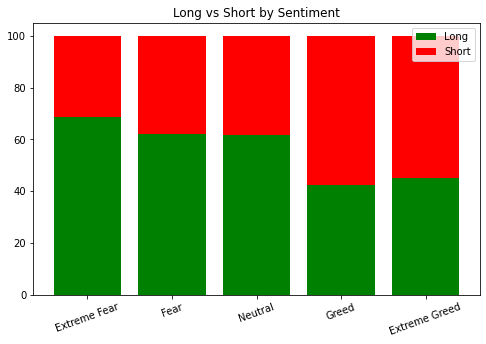

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(order, bias['Open Long'], label='Long', color='green')
plt.bar(order, bias['Open Short'], bottom=bias['Open Long'], label='Short', color='red')
plt.legend()
plt.title('Long vs Short by Sentiment')
plt.xticks(rotation=20)
plt.savefig('chart4_longshort.png')
plt.show()

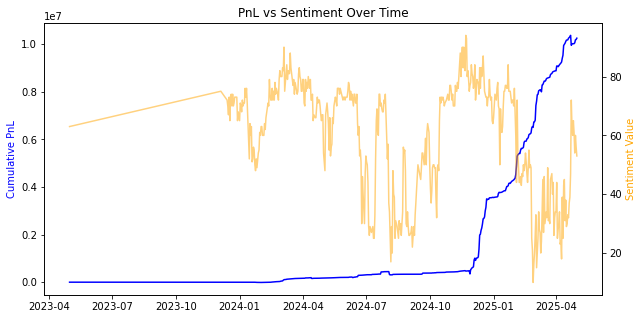

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(daily['date'], daily['cum_pnl'], color='blue')
ax1.set_ylabel('Cumulative PnL', color='blue')
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['value'], color='orange', alpha=0.5)
ax2.set_ylabel('Sentiment Value', color='orange')
plt.title('PnL vs Sentiment Over Time')
plt.savefig('chart5_timeseries.png')
plt.show()

In [15]:
with pd.ExcelWriter('summary.xlsx') as writer:
    summary.to_excel(writer, sheet_name='summary')
    bias.to_excel(writer, sheet_name='long_short')
    acc.to_excel(writer, sheet_name='accounts')
    daily.to_excel(writer, sheet_name='daily')

print('done')

done
